# 🗑️ CLEANIC PROJECT - DATA ENGINEERING PIPELINE
**Versi Modifikasi untuk Penyimpanan Lokal**

## 1️⃣ SETUP & VERIFIKASI LOKAL

In [ ]:
# Dataset lokal sudah tersedia di folder dataset_final/train
import os
print("✅ Setup lokal - Tidak perlu mount Google Drive")

✅ Setup lokal - Tidak perlu mount Google Drive


In [2]:
# ✅ Verifikasi path dataset lokal
dataset_path = r"D:\kuliah\semester_6\stupen\capstone\dataset\dataset_final\train"
print(f"Path Dataset: {dataset_path}")
print(f"Dataset ada: {os.path.exists(dataset_path)}")

# List kelas yang tersedia
if os.path.exists(dataset_path):
    classes = sorted(os.listdir(dataset_path))
    print(f"\nKelas terdeteksi: {classes}")

Path Dataset: D:\kuliah\semester_6\stupen\capstone\dataset\dataset_final\train
Dataset ada: True

Kelas terdeteksi: ['b3', 'kaca', 'kertas', 'logam', 'organik', 'plastik']


In [3]:
# ✅ Hitung gambar di setiap kelas
print("\n" + "="*60)
print("DAFTAR GAMBAR PER KELAS (Dataset Lokal)")
print("="*60)

for cls in sorted(os.listdir(dataset_path)):
    cls_path = os.path.join(dataset_path, cls)
    if os.path.isdir(cls_path):
        count = len([f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.webp'))])
        print(f"{cls}: {count} gambar")


DAFTAR GAMBAR PER KELAS (Dataset Lokal)
b3: 2959 gambar
kaca: 3534 gambar
kertas: 3714 gambar
logam: 3934 gambar
organik: 2954 gambar
plastik: 2662 gambar
b3: 2959 gambar
kaca: 3534 gambar
kertas: 3714 gambar
logam: 3934 gambar
organik: 2954 gambar
plastik: 2662 gambar


## 2️⃣ IMPORT LIBRARY

In [4]:
import os
import shutil
import hashlib
import random
import json
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
from PIL import Image, ImageEnhance, ImageOps
from tqdm import tqdm

# Install imagehash
import subprocess
subprocess.check_call(["pip", "install", "-q", "imagehash"])

import imagehash
import warnings
warnings.filterwarnings('ignore')

print("✅ Semua library berhasil diimport")

✅ Semua library berhasil diimport


## 3️⃣ KONFIGURASI PATH

In [5]:
# ✅ PATH CONFIGURATION UNTUK LOKAL (TIDAK COLAB)

# Path dataset asli (input)
TRAIN_PATH = r"D:\kuliah\semester_6\stupen\capstone\dataset\dataset_final\train"

# Base output directory
OUTPUT_BASE = r"D:\kuliah\semester_6\stupen\capstone\dataset"

# Path output untuk dataset yang sudah dibersihkan & diaugmentasi
CLEAN_PATH = os.path.join(OUTPUT_BASE, "dataset_clean")
ADJUSTED_PATH = os.path.join(OUTPUT_BASE, "dataset_adjusted")
AUG_PATH = os.path.join(OUTPUT_BASE, "dataset_augmented")
FINAL_PATH = os.path.join(OUTPUT_BASE, "dataset_selesai_olah")

# Backup path
BACKUP_PATH = os.path.join(OUTPUT_BASE, "dataset_backup")

# Target jumlah gambar per kelas setelah augmentasi
TARGET_PER_CLASS = 3000

# Ukuran gambar standar
IMG_SIZE = (224, 224)

# Nama kelas (sesuai folder)
CLASSES = sorted(os.listdir(TRAIN_PATH))

# Define OUTPUT_PATH untuk akhir
OUTPUT_PATH = FINAL_PATH

print("\n" + "="*60)
print("KONFIGURASI PATH - LOKAL (NON-COLAB)")
print("="*60)
print(f"📂 Dataset Input   : {TRAIN_PATH}")
print(f"📂 Output Base     : {OUTPUT_BASE}")
print(f"📂 Clean Path      : {CLEAN_PATH}")
print(f"📂 Augmented Path  : {AUG_PATH}")
print(f"📂 Final Output    : {FINAL_PATH}")
print(f"\n⚙️  Target/kelas    : {TARGET_PER_CLASS}")
print(f"⚙️  Ukuran gambar   : {IMG_SIZE}")
print(f"✅ Kelas terdeteksi: {CLASSES}")
print("="*60)


KONFIGURASI PATH - LOKAL (NON-COLAB)
📂 Dataset Input   : D:\kuliah\semester_6\stupen\capstone\dataset\dataset_final\train
📂 Output Base     : D:\kuliah\semester_6\stupen\capstone\dataset
📂 Clean Path      : D:\kuliah\semester_6\stupen\capstone\dataset\dataset_clean
📂 Augmented Path  : D:\kuliah\semester_6\stupen\capstone\dataset\dataset_augmented
📂 Final Output    : D:\kuliah\semester_6\stupen\capstone\dataset\dataset_selesai_olah

⚙️  Target/kelas    : 3000
⚙️  Ukuran gambar   : (224, 224)
✅ Kelas terdeteksi: ['b3', 'kaca', 'kertas', 'logam', 'organik', 'plastik']


In [6]:
# ✅ Buat backup dataset original
if not os.path.exists(BACKUP_PATH):
    print(f"Membuat backup dataset ke {BACKUP_PATH}...")
    shutil.copytree(TRAIN_PATH, BACKUP_PATH)
    print("✅ Backup dataset selesai")
else:
    print(f"✅ Backup dataset sudah ada di {BACKUP_PATH}")

Membuat backup dataset ke D:\kuliah\semester_6\stupen\capstone\dataset\dataset_backup...
✅ Backup dataset selesai
✅ Backup dataset selesai


## 4️⃣ ASSESSING DATA

In [7]:
print("\n" + "="*60)
print(" ASSESSING DATA")
print("="*60)

assess_records = []

for cls in CLASSES:
    cls_path = os.path.join(TRAIN_PATH, cls)
    files = [f for f in os.listdir(cls_path)
             if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.webp'))]

    corrupt_count = 0
    size_list     = []
    mode_list     = []

    for fname in files:
        fpath = os.path.join(cls_path, fname)
        try:
            with Image.open(fpath) as img:
                size_list.append(img.size)
                mode_list.append(img.mode)
        except Exception:
            corrupt_count += 1

    unique_sizes  = len(set(size_list))
    dominant_mode = max(set(mode_list), key=mode_list.count) if mode_list else 'N/A'
    non_rgb       = sum(1 for m in mode_list if m != 'RGB')

    assess_records.append({
        'Kelas'           : cls,
        'Jumlah Gambar'   : len(files),
        'Corrupt'         : corrupt_count,
        'Ukuran Unik'     : unique_sizes,
        'Mode Dominan'    : dominant_mode,
        'Non-RGB'         : non_rgb,
        'Status'          : 'Cukup' if len(files) >= TARGET_PER_CLASS else 'Kurang'
    })

df_assess = pd.DataFrame(assess_records)
print(df_assess.to_string(index=False))

total = df_assess['Jumlah Gambar'].sum()
print(f"\n Total gambar keseluruhan : {total:,}")
print(f" Kelas dengan gambar < {TARGET_PER_CLASS}: "
      f"{df_assess[df_assess['Jumlah Gambar'] < TARGET_PER_CLASS]['Kelas'].tolist()}")


 ASSESSING DATA
  Kelas  Jumlah Gambar  Corrupt  Ukuran Unik Mode Dominan  Non-RGB Status
     b3           2959        0         1953          RGB        7 Kurang
   kaca           3534        0         1087          RGB        2  Cukup
 kertas           3714        0          573          RGB       49  Cukup
  logam           3934        0          610          RGB       19  Cukup
organik           2954        0          493          RGB      424 Kurang
plastik           2662        0         1093          RGB      124 Kurang

 Total gambar keseluruhan : 19,757
 Kelas dengan gambar < 3000: ['b3', 'organik', 'plastik']
  Kelas  Jumlah Gambar  Corrupt  Ukuran Unik Mode Dominan  Non-RGB Status
     b3           2959        0         1953          RGB        7 Kurang
   kaca           3534        0         1087          RGB        2  Cukup
 kertas           3714        0          573          RGB       49  Cukup
  logam           3934        0          610          RGB       19  Cukup
o

### Visualisasi Distribusi Awal

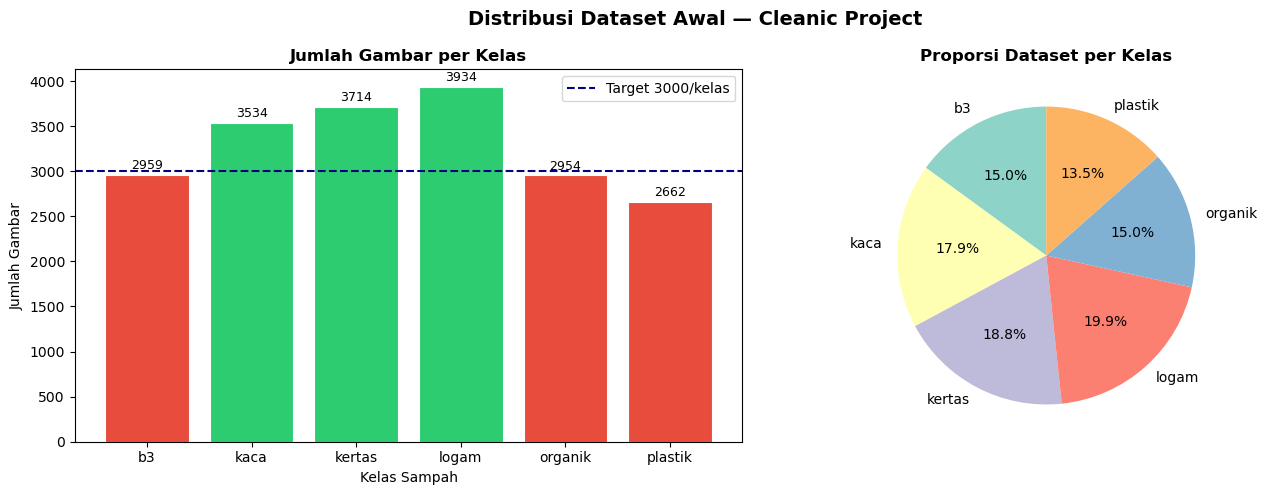

 Grafik distribusi awal disimpan.


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribusi Dataset Awal — Cleanic Project', fontsize=14, fontweight='bold')

# Bar chart jumlah per kelas
colors = ['#2ecc71' if v >= TARGET_PER_CLASS else '#e74c3c'
          for v in df_assess['Jumlah Gambar']]
bars = axes[0].bar(df_assess['Kelas'], df_assess['Jumlah Gambar'],
                   color=colors, edgecolor='white', linewidth=0.8)
axes[0].axhline(y=TARGET_PER_CLASS, color='navy', linestyle='--',
                linewidth=1.5, label=f'Target {TARGET_PER_CLASS}/kelas')
axes[0].set_title('Jumlah Gambar per Kelas', fontweight='bold')
axes[0].set_xlabel('Kelas Sampah')
axes[0].set_ylabel('Jumlah Gambar')
axes[0].legend()
for bar, val in zip(bars, df_assess['Jumlah Gambar']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 str(val), ha='center', va='bottom', fontsize=9)

# Pie chart proporsi
axes[1].pie(df_assess['Jumlah Gambar'], labels=df_assess['Kelas'],
            autopct='%1.1f%%', startangle=90,
            colors=plt.cm.Set3.colors[:len(CLASSES)])
axes[1].set_title('Proporsi Dataset per Kelas', fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_BASE, 'distribusi_awal.png'), dpi=150, bbox_inches='tight')
plt.show()
print(" Grafik distribusi awal disimpan.")

## 5️⃣ CLEANING DATA

In [9]:
print("\n" + "="*60)
print(" CLEANING DATA")
print("="*60)

os.makedirs(CLEAN_PATH, exist_ok=True)
clean_report = []
deleted_log = []

for cls in CLASSES:
    cls_src  = os.path.join(TRAIN_PATH, cls)
    cls_dst  = os.path.join(CLEAN_PATH, cls)
    os.makedirs(cls_dst, exist_ok=True)

    files = [f for f in os.listdir(cls_src)
             if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.webp'))]

    seen_hashes = {}
    saved = 0
    skipped_corrupt = 0
    skipped_dup = 0

    for fname in tqdm(files, desc=f"Cleaning [{cls}]"):
        fpath = os.path.join(cls_src, fname)
        try:
            with Image.open(fpath) as img:
                # Konversi ke RGB
                img_rgb = img.convert('RGB')

                # Hash untuk deteksi duplikat
                phash = str(imagehash.phash(img_rgb))

                if phash in seen_hashes:
                    deleted_log.append({
                        'Kelas': cls,
                        'Nama File': fname,
                        'Alasan': 'Duplikat',
                        'Duplikat Dari': seen_hashes[phash]
                    })
                    skipped_dup += 1
                    continue
                else:
                    seen_hashes[phash] = fname

                # Resize ke 224x224
                img_resized = img_rgb.resize(IMG_SIZE, Image.LANCZOS)

                # Simpan
                save_name = f"{cls}_{saved:05d}.jpg"
                img_resized.save(os.path.join(cls_dst, save_name),
                                 'JPEG', quality=95)
                saved += 1

        except Exception:
            skipped_corrupt += 1
            continue

    clean_report.append({
        'Kelas'           : cls,
        'Asli'            : len(files),
        'Tersimpan'       : saved,
        'Duplikat Hapus'  : skipped_dup,
        'Corrupt Hapus'   : skipped_corrupt
    })
    print(f"  [{cls}] Asli: {len(files)} → Bersih: {saved} "
          f"(hapus duplikat: {skipped_dup}, corrupt: {skipped_corrupt})")

df_clean = pd.DataFrame(clean_report)
print("\n Ringkasan Cleaning:")
print(df_clean.to_string(index=False))


 CLEANING DATA


Cleaning [b3]: 100%|██████████| 2959/2959 [01:26<00:00, 34.16it/s]


  [b3] Asli: 2959 → Bersih: 2942 (hapus duplikat: 17, corrupt: 0)


Cleaning [kaca]: 100%|██████████| 3534/3534 [01:09<00:00, 50.56it/s] 


  [kaca] Asli: 3534 → Bersih: 2886 (hapus duplikat: 648, corrupt: 0)


...

  [logam] Asli: 3934 → Bersih: 2999 (hapus duplikat: 935, corrupt: 0)


Cleaning [organik]: 100%|██████████| 2954/2954 [01:06<00:00, 44.28it/s] 


  [organik] Asli: 2954 → Bersih: 2437 (hapus duplikat: 517, corrupt: 0)


Cleaning [plastik]: 100%|██████████| 2662/2662 [02:00<00:00, 22.04it/s] 


  [plastik] Asli: 2662 → Bersih: 2182 (hapus duplikat: 480, corrupt: 0)

 Ringkasan Cleaning:
  Kelas  Asli  Tersimpan  Duplikat Hapus  Corrupt Hapus
     b3  2959       2942              17              0
   kaca  3534       2886             648              0
 kertas  3714       2860             854              0
  logam  3934       2999             935              0
organik  2954       2437             517              0
plastik  2662       2182             480              0


## 6️⃣ AUGMENTASI DATA

In [10]:
print("\n" + "="*60)
print(" AUGMENTASI DATA (Balancing & Penyesuaian)")
print("="*60)

os.makedirs(AUG_PATH, exist_ok=True)

aug_report = []

for cls in CLASSES:
    cls_clean_path = os.path.join(CLEAN_PATH, cls)
    cls_aug_path = os.path.join(AUG_PATH, cls)
    os.makedirs(cls_aug_path, exist_ok=True)
    
    # Load gambar dari folder clean
    clean_files = [f for f in os.listdir(cls_clean_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    
    current_count = len(clean_files)
    needed_count = max(0, TARGET_PER_CLASS - current_count)
    
    # Copy gambar original
    copied = 0
    for fname in tqdm(clean_files, desc=f"Copying [{cls}]"):
        src = os.path.join(cls_clean_path, fname)
        dst = os.path.join(cls_aug_path, fname)
        shutil.copy2(src, dst)
        copied += 1
    
    # Augmentasi jika diperlukan
    augmented = 0
    if needed_count > 0:
        print(f"  Augmentasi [{cls}]: butuh {needed_count} gambar...")
        random.shuffle(clean_files)
        
        for i in tqdm(range(needed_count), desc=f"Augmenting [{cls}]"):
            src_fname = clean_files[i % len(clean_files)]
            src_path = os.path.join(cls_clean_path, src_fname)
            
            try:
                with Image.open(src_path) as img:
                    img_rgb = img.convert('RGB')
                    
                    # Pilih augmentasi random
                    aug_type = random.choice(['flip_h', 'flip_v', 'rotate', 'brightness', 'contrast'])
                    
                    if aug_type == 'flip_h':
                        img_aug = img_rgb.transpose(Image.FLIP_LEFT_RIGHT)
                    elif aug_type == 'flip_v':
                        img_aug = img_rgb.transpose(Image.FLIP_TOP_BOTTOM)
                    elif aug_type == 'rotate':
                        angle = random.choice([10, -10, 15, -15])
                        img_aug = img_rgb.rotate(angle, fillcolor=(128, 128, 128))
                    elif aug_type == 'brightness':
                        enhancer = ImageEnhance.Brightness(img_rgb)
                        factor = random.uniform(0.8, 1.2)
                        img_aug = enhancer.enhance(factor)
                    else:  # contrast
                        enhancer = ImageEnhance.Contrast(img_rgb)
                        factor = random.uniform(0.8, 1.2)
                        img_aug = enhancer.enhance(factor)
                    
                    # Simpan augmented image
                    aug_name = f"{cls}_aug_{augmented:05d}.jpg"
                    img_aug.save(os.path.join(cls_aug_path, aug_name), 'JPEG', quality=95)
                    augmented += 1
            except:
                continue
    
    total_after_aug = copied + augmented
    aug_report.append({
        'Kelas': cls,
        'Original': current_count,
        'Target': TARGET_PER_CLASS,
        'Augmentasi': augmented,
        'Total': total_after_aug
    })
    
    print(f"  [{cls}] {current_count} → +{augmented} aug → {total_after_aug} total")

df_aug = pd.DataFrame(aug_report)
print("\n Ringkasan Augmentasi:")
print(df_aug.to_string(index=False))
print(f"\n✅ Augmentasi selesai. Dataset tersimpan di: {AUG_PATH}")


 AUGMENTASI DATA (Balancing & Penyesuaian)


Copying [b3]: 100%|██████████| 2942/2942 [00:26<00:00, 111.13it/s]


  Augmentasi [b3]: butuh 58 gambar...


Augmenting [b3]: 100%|██████████| 58/58 [00:00<00:00, 99.95it/s] 


  [b3] 2942 → +58 aug → 3000 total


...

  [organik] 2437 → +563 aug → 3000 total


Copying [plastik]: 100%|██████████| 2182/2182 [00:00<00:00, 2427.46it/s]


  Augmentasi [plastik]: butuh 818 gambar...


Augmenting [plastik]: 100%|██████████| 818/818 [00:08<00:00, 98.54it/s] 

  [plastik] 2182 → +818 aug → 3000 total

 Ringkasan Augmentasi:
  Kelas  Original  Target  Augmentasi  Total
     b3      2942    3000          58   3000
   kaca      2886    3000         114   3000
 kertas      2860    3000         140   3000
  logam      2999    3000           1   3000
organik      2437    3000         563   3000
plastik      2182    3000         818   3000

✅ Augmentasi selesai. Dataset tersimpan di: D:\kuliah\semester_6\stupen\capstone\dataset\dataset_augmented


## 7️⃣ SPLIT DATASET (Train/Val/Test)

In [11]:
print("\n" + "="*60)
print(" SPLIT DATASET (Train 80% | Val 10% | Test 10%)")
print("="*60)

# Reset folder final
if os.path.exists(FINAL_PATH):
    shutil.rmtree(FINAL_PATH)

# Buat struktur folder
for split in ['train', 'val', 'test']:
    for cls in os.listdir(AUG_PATH):
        os.makedirs(os.path.join(FINAL_PATH, split, cls), exist_ok=True)

split_report = []

for cls in os.listdir(AUG_PATH):
    cls_aug_path = os.path.join(AUG_PATH, cls)

    files = [f for f in os.listdir(cls_aug_path)
             if f.lower().endswith(('.jpg','.png','.jpeg'))]

    random.shuffle(files)

    n = len(files)
    n_train = int(n * 0.80)
    n_val   = int(n * 0.10)

    splits = {
        'train': files[:n_train],
        'val'  : files[n_train:n_train + n_val],
        'test' : files[n_train + n_val:]
    }

    for split_name, split_files in splits.items():
        for fname in tqdm(split_files, desc=f"Copying {split_name}/{cls}"):
            shutil.copy2(
                os.path.join(cls_aug_path, fname),
                os.path.join(FINAL_PATH, split_name, cls, fname)
            )

    split_report.append({
        'Kelas' : cls,
        'Train' : len(splits['train']),
        'Val'   : len(splits['val']),
        'Test'  : len(splits['test']),
        'Total' : n
    })

df_split = pd.DataFrame(split_report)
print(df_split.to_string(index=False))

print(f"\n✅ Dataset final tersimpan di: {FINAL_PATH}")


 SPLIT DATASET (Train 80% | Val 10% | Test 10%)


Copying test/plastik: 100%|██████████| 300/300 [00:02<00:00, 135.15it/s]

  Kelas  Train  Val  Test  Total
     b3   2400  300   300   3000
   kaca   2400  300   300   3000
 kertas   2400  300   300   3000
  logam   2400  300   300   3000
organik   2400  300   300   3000
plastik   2400  300   300   3000

✅ Dataset final tersimpan di: D:\kuliah\semester_6\stupen\capstone\dataset\dataset_selesai_olah


## 8️⃣ VISUALISASI HASIL

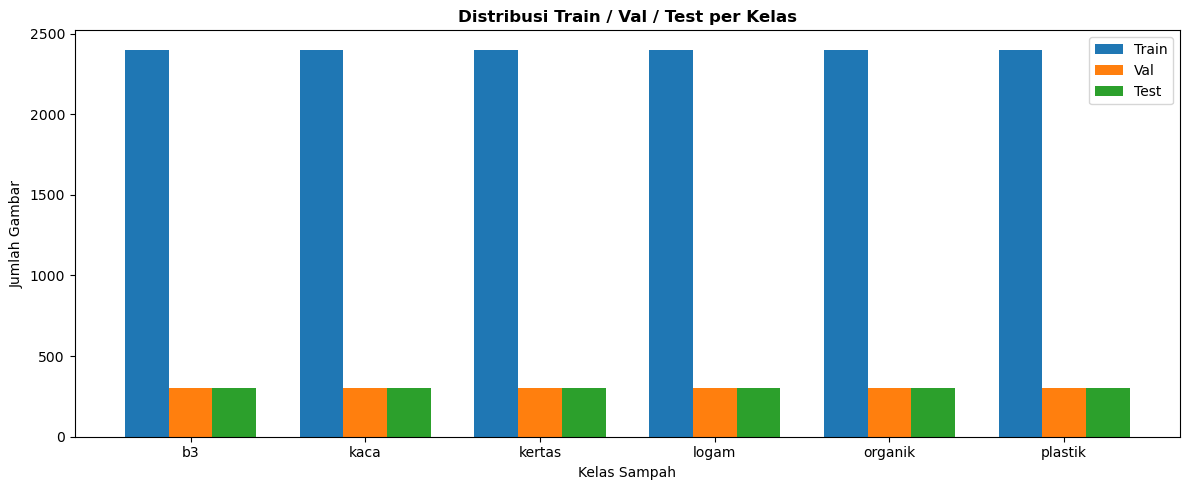

 Grafik split disimpan.


In [12]:
# Bar chart Split
fig, ax = plt.subplots(figsize=(12, 5))

df_split_sorted = df_split.sort_values('Kelas').reset_index(drop=True)

x = np.arange(len(df_split_sorted))
width = 0.25

bars1 = ax.bar(x - width, df_split_sorted['Train'], width, label='Train')
bars2 = ax.bar(x,         df_split_sorted['Val'],   width, label='Val')
bars3 = ax.bar(x + width, df_split_sorted['Test'],  width, label='Test')

ax.set_xlabel('Kelas Sampah')
ax.set_ylabel('Jumlah Gambar')
ax.set_title('Distribusi Train / Val / Test per Kelas', fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(df_split_sorted['Kelas'])

ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_BASE, 'split_train_val_test.png'), dpi=150, bbox_inches='tight')
plt.show()

print(" Grafik split disimpan.")

## 9️⃣ DATA DICTIONARY

In [13]:
print("\n" + "="*60)
print(" DATA DICTIONARY")
print("="*60)

classes = sorted(df_clean['Kelas'].unique())

# Define class_meta dictionary
class_meta = {
    'b3': {
        'deskripsi': 'Bahan Berbahaya dan Beracun (B3), contohnya baterai, aki, elektronik, cat, pestisida.',
        '3R_utama': 'Reuse, Recycle',
        'bahaya': 'Tinggi'
    },
    'kaca': {
        'deskripsi': 'Sampah berbahan dasar kaca, contohnya botol kaca, pecahan kaca, toples.',
        '3R_utama': 'Recycle, Reuse',
        'bahaya': 'Sedang'
    },
    'kertas': {
        'deskripsi': 'Sampah berbahan dasar kertas, contohnya koran, kardus, buku, kemasan kertas.',
        '3R_utama': 'Recycle, Reuse',
        'bahaya': 'Rendah'
    },
    'logam': {
        'deskripsi': 'Sampah berbahan dasar logam, contohnya kaleng, aluminium foil, besi.',
        '3R_utama': 'Recycle, Reuse',
        'bahaya': 'Rendah'
    },
    'organik': {
        'deskripsi': 'Sampah organik, mudah terurai, contohnya sisa makanan, daun, ranting.',
        '3R_utama': 'Compost, Reuse',
        'bahaya': 'Rendah'
    },
    'plastik': {
        'deskripsi': 'Sampah berbahan dasar plastik, contohnya botol plastik, kantong plastik, kemasan sachet.',
        '3R_utama': 'Recycle, Reuse',
        'bahaya': 'Sedang'
    }
}

dict_records = []

for cls in classes:
    meta = class_meta.get(cls, {})

    # Ambil data raw
    raw_match = df_assess[df_assess['Kelas'] == cls]
    raw_count = raw_match['Jumlah Gambar'].values[0] if not raw_match.empty else 0

    # Ambil data clean
    clean_match = df_clean[df_clean['Kelas'] == cls]
    clean_count = clean_match['Tersimpan'].values[0] if not clean_match.empty else 0

    # Ambil data split
    split_match = df_split[df_split['Kelas'] == cls]
    split_row = split_match.iloc[0] if not split_match.empty else {}

    dict_records.append({
        'Kelas'          : cls,
        'Deskripsi'      : meta.get('deskripsi', '-'),
        '3R Utama'       : meta.get('3R_utama', '-'),
        'Tingkat Bahaya' : meta.get('bahaya', '-'),
        'Jumlah Raw'     : raw_count,
        'Jumlah Clean'   : clean_count,
        'Train'          : split_row.get('Train', 0),
        'Val'            : split_row.get('Val', 0),
        'Test'           : split_row.get('Test', 0),
        'Ukuran Gambar'  : '224x224 px',
        'Format'         : 'JPEG / RGB',
    })

df_dict = pd.DataFrame(dict_records)

print(df_dict.to_string(index=False))

df_dict.to_csv(os.path.join(OUTPUT_BASE, 'data_dictionary_cleanic.csv'), index=False)

print("\n Data Dictionary disimpan.")


 DATA DICTIONARY
  Kelas                                                                                Deskripsi       3R Utama Tingkat Bahaya  Jumlah Raw  Jumlah Clean  Train  Val  Test Ukuran Gambar     Format
     b3    Bahan Berbahaya dan Beracun (B3), contohnya baterai, aki, elektronik, cat, pestisida. Reuse, Recycle         Tinggi        2959          2942   2400  300   300    224x224 px JPEG / RGB
   kaca                  Sampah berbahan dasar kaca, contohnya botol kaca, pecahan kaca, toples. Recycle, Reuse         Sedang        3534          2886   2400  300   300    224x224 px JPEG / RGB
 kertas             Sampah berbahan dasar kertas, contohnya koran, kardus, buku, kemasan kertas. Recycle, Reuse         Rendah        3714          2860   2400  300   300    224x224 px JPEG / RGB
  logam                     Sampah berbahan dasar logam, contohnya kaleng, aluminium foil, besi. Recycle, Reuse         Rendah        3934          2999   2400  300   300    224x224 px JPEG / RGB
or

## 🔟 SIMPAN SEMUA OUTPUT

In [ ]:
import os, shutil

print("\n" + "="*60)
print("MENYIMPAN OUTPUT KE PENYIMPANAN LOKAL")
print("="*60)

saved_files = []
saved_folders = []

# 1️⃣ Simpan semua file visualisasi (.png dan .csv) ke folder output utama
print("\n[1️⃣] Menyimpan file visualisasi (.png, .csv)...")
output_reports_path = os.path.join(OUTPUT_BASE, "reports")
os.makedirs(output_reports_path, exist_ok=True)

for fname in os.listdir(OUTPUT_BASE):
    if fname.endswith(('.png', '.csv')):
        src = os.path.join(OUTPUT_BASE, fname)
        if os.path.isfile(src):
            dst = os.path.join(output_reports_path, fname)
            try:
                shutil.copy2(src, dst)
                saved_files.append(fname)
                print(f"   ✅ {fname}")
            except Exception as e:
                print(f"   ❌ Gagal copy {fname}: {e}")

# 2️⃣ Verifikasi folder dataset_selesai_olah
print("\n[2️⃣] Memverifikasi folder output final...")
if os.path.exists(FINAL_PATH):
    print(f"   ✅ Folder {FINAL_PATH} sudah ada")
    
    # Hitung total gambar di folder final
    total_images = 0
    for split in ['train', 'val', 'test']:
        split_path = os.path.join(FINAL_PATH, split)
        if os.path.exists(split_path):
            for cls in os.listdir(split_path):
                cls_path = os.path.join(split_path, cls)
                if os.path.isdir(cls_path):
                    count = len(os.listdir(cls_path))
                    total_images += count
    
    print(f"   📊 Total gambar di folder final: {total_images:,}")
else:
    print(f"   ⚠️  Folder {FINAL_PATH} tidak ditemukan")

# 3️⃣ Informasi struktur output
print("\n[3️⃣] Struktur output akhir:")
print(f"   📂 {OUTPUT_BASE}/")
print(f"      ├── 📁 dataset_clean/")
print(f"      ├── 📁 dataset_augmented/")
print(f"      ├── 📁 dataset_selesai_olah/  [✅ MAIN OUTPUT]")
print(f"      │   ├── train/")
print(f"      │   ├── val/")
print(f"      │   └── test/")
print(f"      └── 📁 reports/")
print(f"          ├── *.png (visualisasi)")
print(f"          └── *.csv (data dictionary)")

print("\n" + "="*60)
print(f"✅ Total file laporan tersimpan: {len(saved_files)}")
print(f"📍 Lokasi output utama: {OUTPUT_BASE}")
print(f"📁 Dataset final: {FINAL_PATH}")
print("="*60)

print("\n🎉 PIPELINE DATA ENGINEERING CLEANIC SELESAI!")
print("="*60)
print("✨ Output utama tersedia di:")
print(f"   {FINAL_PATH}")
print("="*60)


MENYIMPAN OUTPUT KE PENYIMPANAN LOKAL

[1️⃣] Menyimpan file visualisasi (.png, .csv)...
   ✅ data_dictionary_cleanic.csv
   ✅ distribusi_awal.png
   ✅ split_train_val_test.png

[2️⃣] Memverifikasi folder output final...
   ✅ Folder D:\kuliah\semester_6\stupen\capstone\dataset\dataset_selesai_olah sudah ada
   📊 Total gambar di folder final: 18,000

[3️⃣] Struktur output akhir:
   📂 D:\kuliah\semester_6\stupen\capstone\dataset/
      ├── 📁 dataset_clean/
      ├── 📁 dataset_augmented/
      ├── 📁 dataset_selesai_olah/  [✅ MAIN OUTPUT]
      │   ├── train/
      │   ├── val/
      │   └── test/
      └── 📁 reports/
          ├── *.png (visualisasi)
          └── *.csv (data dictionary)

✅ Total file laporan tersimpan: 3
📍 Lokasi output utama: D:\kuliah\semester_6\stupen\capstone\dataset
📁 Dataset final: D:\kuliah\semester_6\stupen\capstone\dataset\dataset_selesai_olah

🎉 PIPELINE DATA ENGINEERING CLEANIC SELESAI!
✨ Output utama tersedia di:
   D:\kuliah\semester_6\stupen\capstone\datase